In [288]:
'''######################### ottimi risultati senza clahe #############

import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

#### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_17.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_01.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])

plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()

######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########
img_blur = cv2.GaussianBlur(img,(7,7),1.5)
circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi) (per il canny "integrato") - + alta mi trova solo il cerchio esterno
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])


cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
plt.imshow(img_color)
plt.show()

#### ROI OF INSIDE THE CAP
offset = ((radius/math.sqrt(2))+radius)/2 # half way
offset = radius*0.8 # accazzodicane ##################################
x_max=math.ceil(center[0]+offset)
x_min=math.floor(center[0]-offset)
y_max=math.ceil(center[1]+offset)
y_min=math.floor(center[1]-offset)  

img_roi=img_blur[y_min:y_max,x_min:x_max]
img_roi_show=cv2.cvtColor(img_roi, cv2.COLOR_GRAY2RGB)



########## TASK 1.2 : identifica rotture liner

edges = cv2.Canny(img_roi,15,30,apertureSize = 3)
#edges = cv2.Canny(img_roi,10,30,apertureSize = 3) #VERY NICE
plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
plt.show() 
line_layer=np.zeros_like(img_color) ############################################################################################################# PROVA PER RIQUADRO

lines = cv2.HoughLines(edges,1,np.pi/180,70)
if lines is not None and len(lines) > 0:
    #
    
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho    
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        print("LINE: (",x0,",",y0,") - theta= ",theta," - rho: ",rho)
        cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.line(img_color, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2)
        
        
    
    rho, theta = lines[0][0] 
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    
    cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.line(img_color, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2)

    
    
    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_roi_show)
    plt.subplot(1,2,2)
    plt.imshow(img_color)
    plt.show()
    

    # PROVARE A FARE LA MEDIA DELLE LINEE CHE TROVA PER AVERNE SOLO UNA
    rho_mean=sum(lines[:,0,0])/len(lines)
    theta_mean=sum(lines[:,0,1])/len(lines)
    a = np.cos(theta_mean)
    b = np.sin(theta_mean)
    x0 = a * rho_mean
    y0 = b * rho_mean
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    print("LINE: (",x0,",",y0,") - theta= ",theta_mean," - rho: ",rho_mean)

    cv2.line(line_layer, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2) ###################################################################### PROVA PER RIQUADRO
    ############### nel programma vero e proprio io non la metterei la linea blu nell'immagine finale...
    ############### potremmo fare un if per cui se vogliamo visualizzare step per step allora ci mette la linea su una copia di img_color per vederla

    cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.line(img_color, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2)

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_roi_show)
    plt.subplot(1,2,2)
    plt.imshow(img_color)
    plt.show()
    
    
    #### funziona bene con tutte c'è solo da capire come fare il rettangolo
else: 
    print("NO DEFECTS")

# houghlinesP : fa le linee "limitate" non infinite ma è peggio a prendere le linee complete perchè sono un po' stortine
linesP = cv2.HoughLinesP(edges,1,np.pi/180,60,minLineLength=50,maxLineGap=60)
#linesP = cv2.HoughLinesP(edges,1,np.pi/180,50,minLineLength=50,maxLineGap=58) # perfetta per d17

if linesP is not None and len(linesP) > 0:
    #
    for line in linesP:
        x1,y1,x2,y2= line[0]
        cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
  

    #x1,y1,x2,y2 = linesP[0][0] 
    #cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
   
    plt.figure()
    plt.imshow(img_color)
    plt.show()




##### TASK 1.3: missing liner

fare region of interest nel cerchio piccolo (si può fare circolare)
fare la avg lightness di altre immagini e trovare il valore medio più diffuso e se è più chiara allora è senza liner  



######## TASK 2:  Outline the cap by generating a circle that fits the cap mouth 
circle_liner_layer=np.zeros_like(img_color) ################################################################################################### PROVA PER RIQUADRO
circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 50,param1=40,param2=60) # d_18 ne trova 3 ma il primo è quello giusto
#circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 45,param1=40,param2=60) # ALL OK EXCEPT G_04 if keep "half way" ROI
#cerchiamo il cerchio interno nella roi e poi per visualizzarlo gli diamo l'offset per ritrovarlo nell'immagine grande ((0,0) in img_roi = (x_min,y_min) in img "full")
# !!!!!!!!!!!11 d_31 questa non la trova (che ci sta che sia così)
if circles_in is not None and len(circles_in) > 0:

    #print(circles, circles.shape)
    for c in circles_in[0,:] : 
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(c[2]),color=(255, 0, 0),thickness=2)
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(2),color=(255,0, 0),thickness=2)
        cv2.circle(img_color,(int(c[0])+x_min,int(c[1])+y_min),int(c[2]),color=(255, 0, 0),thickness=2)
        cv2.circle(img_color,(int(c[0])+x_min,int(c[1])+y_min),int(2),color=(255,0, 0),thickness=2)
        print("LINER - center (in roi pic): x= ", c[0]," y= ",c[1]," - center (in full pic): x= ", c[0]+x_min," y= ",c[1]+y_min," , radius= ",c[2])


        cv2.circle(circle_liner_layer,(int(c[0])+x_min,int(c[1])+y_min),int(c[2]),color=(255,0, 0),thickness=2)################################# PROVA PER RIQUADRO

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_roi_show)
    plt.subplot(1,2,2)
    plt.imshow(img_color)
    plt.show()
else : 
    print("NO LINER")

plt.figure()
plt.title("final result")
plt.imshow(img_color)
plt.show()'''

'######################### ottimi risultati senza clahe #############\n\nimport numpy as np\nimport cv2\nfrom matplotlib import pyplot as plt\nimport math\n\n#### LOAD and show IMAGE\nimg_color = cv2.imread(\'cap-inspection-images/project_1_liner_inspection/d_17.bmp\')\n#img_color = cv2.imread(\'cap-inspection-images/project_1_liner_inspection/g_01.bmp\')\nimg = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)\nplt.figure()\nplt.imshow(img,cmap=\'gray\',vmin=0,vmax=255)\nplt.show()\n\n#### histogram \nhist, bins = np.histogram(img.flatten(), 256, [0,256])\n\nplt.figure(2,figsize=[8,4])\nplt.stem(hist)\nplt.show()\n\n######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########\nimg_blur = cv2.GaussianBlur(img,(7,7),1.5)\ncircles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi\n# param1: threshold della differenza del gradiente (+alto = colori + diversi) (per il canny "integrato") - + alta mi trova so

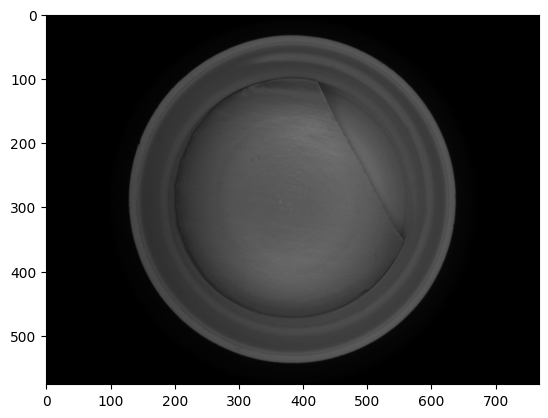

CAP OUTLINE - center: x=  382.5  y=  287.5  , radius=  254.6


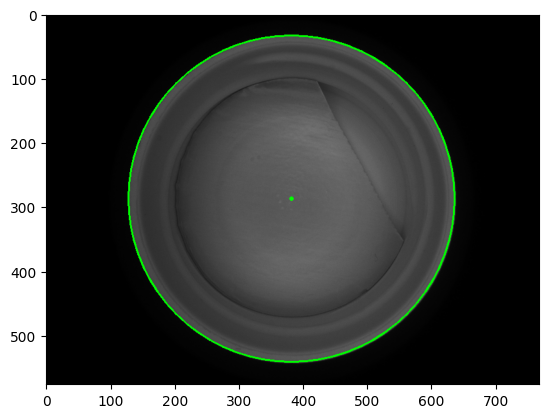

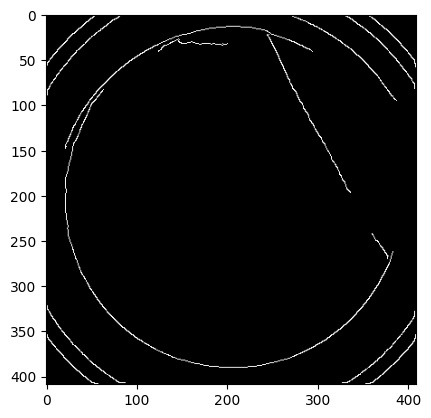

LINE: ( 184.08194 , -93.79446 ) - theta=  2.6703537  - rho:  -206.6


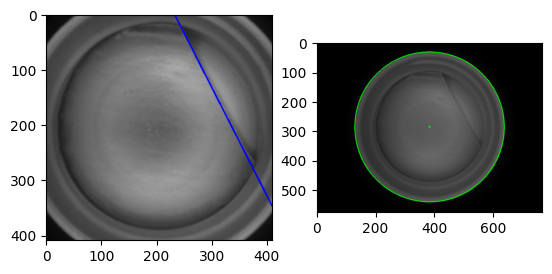

LINER - center (in roi pic): x=  205.5  y=  206.5  - center (in full pic): x=  383.5  y=  289.5  , radius=  184.0


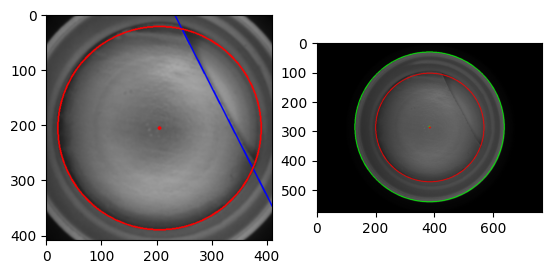

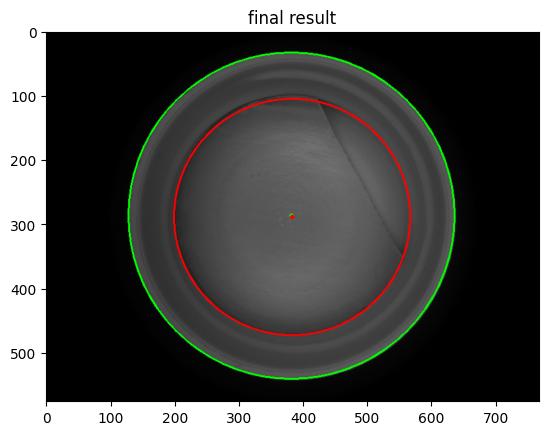

In [1]:
############################## con clahe ######################


import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

#### LOAD and show IMAGE
img_name="d_18"
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/'+img_name+'.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_01.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5))
img_cl = clahe.apply(img)
img_blur = cv2.GaussianBlur(img_cl,(7,7),1.5)



######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########

info_cap=""
info_defect=""
info_liner=""

circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 40,param1=100,param2=80) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi) (per il canny "integrato") - + alta mi trova solo il cerchio esterno
# param2 : perfezione del cerchio

##### tuned so that it finds only one circle

center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
info_cap="CAP OUTLINE - center: x= "+str(center[0])+" y= "+str(center[1])+" , radius= "+str(radius) 
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
plt.imshow(img_color)
plt.show()

#### ROI OF INSIDE THE CAP
offset = ((radius/math.sqrt(2))+radius)/2 # half way
offset = radius*0.8 # accazzodicane ##################################
x_max=math.ceil(center[0]+offset)
x_min=math.floor(center[0]-offset)
y_max=math.ceil(center[1]+offset)
y_min=math.floor(center[1]-offset)  

img_roi=img_blur[y_min:y_max,x_min:x_max]
img_roi_show=cv2.cvtColor(img_roi, cv2.COLOR_GRAY2RGB)



########## TASK 1.2: trova liner si/no



circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 50,param1=90,param2=80) # d_18 ne trova 3 ma il primo è quello giusto
#circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 45,param1=40,param2=60) # ALL OK EXCEPT G_04 if keep "half way" ROI
#cerchiamo il cerchio interno nella roi e poi per visualizzarlo gli diamo l'offset per ritrovarlo nell'immagine grande ((0,0) in img_roi = (x_min,y_min) in img "full")
# !!!!!!!!!!!11 d_31 questa non la trova (che ci sta che sia così)

line_layer=np.zeros_like(img_color) ############################################################################################################# PROVA PER RIQUADRO

if circles_in is not None and len(circles_in) > 0:
    # se liner si 
    ################## TASK 1.3 : TROVA DIFETTO

    edges = cv2.Canny(img_roi,40,80,apertureSize = 3)
    plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
    plt.show() 
    

    lines = cv2.HoughLines(edges,1,np.pi/180,70)
    if lines is not None and len(lines) > 0:
        info_defect="LINER DEFECT DETECTED"
        
        rho_mean=sum(lines[:,0,0])/len(lines)
        theta_mean=sum(lines[:,0,1])/len(lines)
        a = np.cos(theta_mean)
        b = np.sin(theta_mean)
        x0 = a * rho_mean
        y0 = b * rho_mean
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        print("LINE: (",x0,",",y0,") - theta= ",theta_mean," - rho: ",rho_mean)

        cv2.line(line_layer, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2) ###################################################################### PROVA PER RIQUADRO
        ############### nel programma vero e proprio io non la metterei la linea blu nell'immagine finale...
        ############### potremmo fare un if per cui se vogliamo visualizzare step per step allora ci mette la linea su una copia di img_color per vederla

        cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
        #cv2.line(img_color, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2)

        plt.figure()
        plt.subplot(1,2,1)
        plt.imshow(img_roi_show)
        plt.subplot(1,2,2)
        plt.imshow(img_color)
        plt.show()
        
        
        #### funziona bene con tutte c'è solo da capire come fare il rettangolo
    else: 
        info_defect="NO DEFECTS"
        print("NO DEFECTS")
        

    ####  spostare tutta la parte del riquadro qua

else : 
    info_liner="NO LINER"
    print("NO LINER")




######## TASK 2:  Outline the cap by generating a circle that fits the cap mouth 
circle_liner_layer=np.zeros_like(img_color) ################################################################################################### PROVA PER RIQUADRO

if circles_in is not None and len(circles_in) > 0:

    #print(circles, circles.shape)
    for c in circles_in[0,:] : 
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(c[2]),color=(255, 0, 0),thickness=2)
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(2),color=(255,0, 0),thickness=2)
        cv2.circle(img_color,(int(c[0])+x_min,int(c[1])+y_min),int(c[2]),color=(255, 0, 0),thickness=2)
        cv2.circle(img_color,(int(c[0])+x_min,int(c[1])+y_min),int(2),color=(255,0, 0),thickness=2)
        print("LINER - center (in roi pic): x= ", c[0]," y= ",c[1]," - center (in full pic): x= ", c[0]+x_min," y= ",c[1]+y_min," , radius= ",c[2])
        info_liner="LINER - center : x= "+ str(c[0]+x_min)+" y= "+str(c[1]+y_min)+" , radius= "+str(c[2])

        cv2.circle(circle_liner_layer,(int(c[0])+x_min,int(c[1])+y_min),int(c[2]),color=(255,0, 0),thickness=2)################################# PROVA PER RIQUADRO

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_roi_show)
    plt.subplot(1,2,2)
    plt.imshow(img_color)
    plt.show()
else : 
    print("NO LINER")

plt.figure()
plt.title("final result")
plt.imshow(img_color)
plt.show()

In [2]:
############## prova per trovare riquadro difetto
# IDEA: find the intersection between liner contur and defect line
# line is blue so (0, 0, 255)
# circle is red so (255, 0, 0)
# both have thickness 2pxls so i expect to find 2 "groups" or at the very least 2 pixels that are (255,0,255) in iimg_color

#sarebbe meglio trovare un modo fatto un po' meglio maybe con l'inclinazione del tratto


liner_layer=line_layer+circle_liner_layer
mask = np.all(liner_layer == np.array([255, 0, 255], dtype=np.uint8), axis=2)
y, x = np.where(mask) 
#2 lists with some points of which to make sure i only get two that are in the two different intersections i take the first and last
if len(x)!=0 : 
    x1=x[0]
    y1=y[0]
    x2=x[-1]
    y2=y[-1]

    dx = x2 - x1
    dy = y2 - y1
    length = math.sqrt(dx**2+dy**2)

    if length > 0:
        # Calculate perpendicular unit normal vector
        phix = -dy / length
        phiy = dx / length
        
        # Define how wide you want the rectangle to be on each side of the line
        width = 15
        
        # Calculate the four corners dynamically
        pt1 = [x1 + width *phix, y1 + width * phiy]
        pt2 = [x1 - width *phix, y1 - width * phiy]
        pt3 = [x2 - width *phix, y2 - width * phiy]
        pt4 = [x2 + width *phix, y2 + width * phiy]
        
        # Format the points into an array for OpenCV
        pts = np.array([pt1, pt2, pt3, pt4], dtype=np.int32)
        
        
        cv2.fillPoly(liner_layer, [pts], color=(255, 0, 255))        ###################### per lucreziata vedi dopo
        cv2.polylines(img_color, [pts], isClosed=True, color=(255, 0, 255), thickness=2)



Minor defects found: 1


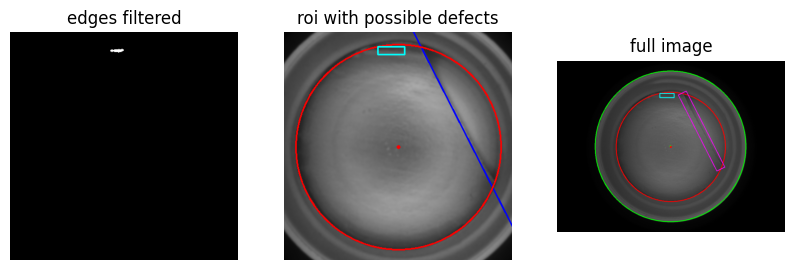

In [3]:
################### LUCREZIATA: IDENTIFY MINOR DEFECTS/IMPERFECTIONS

# 1) Create circular mask from circles_in to keep only inside liner contour (roi coords)
h_roi, w_roi = img_roi.shape[:2]
circle_mask = np.zeros((h_roi, w_roi), dtype=np.uint8)
if circles_in is not None and len(circles_in) > 0:
    for c in circles_in[0, :]:
        cx, cy, cr = int(round(c[0])), int(round(c[1])), int(round(c[2]*0.95)) #reduce the radius a little bit
        cv2.circle(circle_mask, (cx, cy), cr, 255, thickness=-1)
else:
    circle_mask[:] = 255  # no inner circle found -> keep whole roi

# 2) Canny edges (as used before)
edges_small = cv2.Canny(img_roi, 30, 80, apertureSize=3)

# 3) Exclude the rectangle/filled polygon found before:
#    liner_layer is full-image; crop it to roi coordinates (x_min,y_min defined earlier)
liner_crop = liner_layer[y_min:y_max, x_min:x_max]  # shape should match img_roi
# if liner_crop is colored, consider non-zero pixels as mask
if liner_crop.shape[:2] == (h_roi, w_roi):
    rect_mask = np.any(liner_crop != 0, axis=2)  # True where rectangle/poly exists
    edges_small[rect_mask] = 0                   # remove those edges
# else: if shapes mismatch, skip removing rect

# 4) Also remove everything outside the circle (keep only inside liner)
edges_small[circle_mask == 0] = 0

# 5) Find connected components on remaining edges (8-connectivity)

# perform opening/dilation so that the edges are not as thin
# opening removes small noise, dilation thickens the remaining edges

kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
edges_small = cv2.dilate(edges_small, kernel_dilate, iterations=1)

#kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
#edges_small = cv2.morphologyEx(edges_small, cv2.MORPH_OPEN, kernel_open, iterations=1)

n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(edges_small, connectivity=8)

# 6) Filter small components (tunable thresholds) and draw small circles around them
min_area = 50   # ignore specks smaller than this
max_area = 1000 # ignore huge components (not minor)
detected = 0
for lab in range(1, n_labels):
    area = int(stats[lab, cv2.CC_STAT_AREA])
    if area < min_area or area > max_area:
        continue

    # bounding box from connectedComponentsWithStats: left, top, width, height
    left = int(stats[lab, cv2.CC_STAT_LEFT])
    top = int(stats[lab, cv2.CC_STAT_TOP])
    w = int(stats[lab, cv2.CC_STAT_WIDTH])
    h = int(stats[lab, cv2.CC_STAT_HEIGHT])

    ## make the bb bigger (double it)
    left=int(left-(w/2))
    top=int(top-(h/2))
    w=int(w*2)
    h=int(h*2)

    # draw rectangle on roi visualization and on full image (with offset)
    cv2.rectangle(img_roi_show, (left, top), (left + w, top + h), (0, 255, 255), 2)
    cv2.rectangle(img_color, (left + x_min, top + y_min), (left + w + x_min, top + h + y_min), (0, 255, 255), 2)

    detected += 1

print(f"Minor defects found: {detected}")

# 7) Visualize results
plt.figure(figsize=(10,5))
plt.subplot(1,3,1); plt.title("edges filtered"); plt.imshow(edges_small, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("roi with possible defects"); plt.imshow(img_roi_show); plt.axis('off')
plt.subplot(1,3,3); plt.title("full image"); plt.imshow(img_color); plt.axis('off')
plt.show()


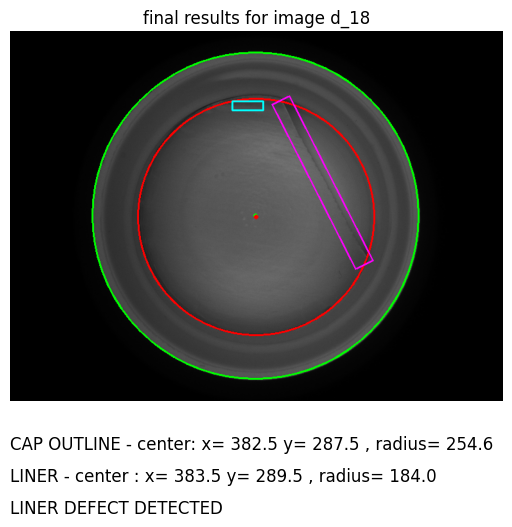

In [4]:
plt.figure()
plt.title("final results for image "+img_name)
plt.text(0,650,info_cap,fontsize=12)
plt.text(0,700,info_liner,fontsize=12)
plt.text(0,750,info_defect,fontsize=12)
plt.imshow(img_color)
plt.axis('off')

#plt.savefig("prova_output_finalresults_"+img_name+".png") ### non funzia molto bene si puo fare manualmente da sotto

plt.show()



In [293]:
save_img = cv2.cvtColor(img_color, cv2.COLOR_RGB2BGR)
#cv2.imwrite("results_"+img_name+".jpg", save_img)

LINK SE VOGLIAMO FARE UNA SEZIONE FINALE BIBLIOGRAFIA:

https://docs.opencv.org/3.4/dc/da5/tutorial_py_drawing_functions.html

https://opencv.org/edge-detection-using-opencv/#h-sobel-operator - https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html (non l'ho usato irl ma me lo tengo che aveva robe utili)

https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html (